<h2>Amogh Sahore<br>
2547108<br>
Machine Learning ETE</h2>

# Q5: Iris Classification using MLP Classifiers

## 1. Imports and setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42

## 2. Load and inspect the dataset

In [12]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

print(f'Dataset shape: {X.shape}')
print(f'Classes: {list(iris.target_names)}')
display(X.head())
display(X.describe().T)

Dataset shape: (150, 4)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 3. Data-quality checks

In [13]:
quality_report = pd.DataFrame({
    'missing_values': X.isna().sum(),
    'missing_percentage': (X.isna().mean() * 100).round(2)
})
display(quality_report)
print(f'Duplicate feature rows: {X.duplicated().sum()}')

,missing_values,missing_percentage
sepal length (cm),0,0.0
sepal width (cm),0,0.0
petal length (cm),0,0.0
petal width (cm),0,0.0


Duplicate feature rows: 1


,class_name,count
0,setosa,50
1,versicolor,50
2,virginica,50


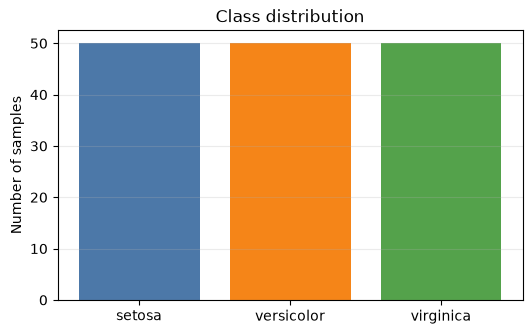

In [14]:
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    'class_name': iris.target_names,
    'count': class_counts.values
})
display(class_distribution)

plt.figure(figsize=(6, 3.5))
plt.bar(iris.target_names, class_counts.values, color=['#4C78A8', '#F58518', '#54A24B'])
plt.title('Class distribution')
plt.ylabel('Number of samples')
plt.grid(axis='y', alpha=0.25)
plt.show()

## 4. Create training and test sets

The test set is kept separate. Cross-validation is performed only on the training set for a fair architecture comparison.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 120
Test samples: 30


## 5. Define the MLP architectures

Feature scaling is included inside each pipeline because MLP training is sensitive to feature magnitudes. `lbfgs` is used because it is well suited to this small dataset.

In [16]:
mlp_one_hidden_layer = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(8,), solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE
    )),
])

mlp_two_hidden_layers = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(8, 4), solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE
    )),
])

architectures = {
    'MLP: (8)': mlp_one_hidden_layer,
    'MLP: (8, 4)': mlp_two_hidden_layers
}

## 6. Cross-validation comparison

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in architectures.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring='accuracy', return_train_score=False)
    cv_rows.append({
        'Architecture': name,
        'Fold accuracies': np.round(scores['test_score'], 3),
        'Mean CV accuracy': scores['test_score'].mean(),
        'Std. CV accuracy': scores['test_score'].std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('Mean CV accuracy', ascending=False).reset_index(drop=True)
display(cv_results)

,Architecture,Fold accuracies,Mean CV accuracy,Std. CV accuracy
0,"MLP: (8, 4)","[0.958, 1.0, 0.958, 0.958, 0.917]",0.958333,0.026352
1,MLP: (8),"[0.958, 1.0, 0.917, 0.958, 0.917]",0.950000,0.031180


## 7. Select and fit the better architecture

In [18]:
best_name = cv_results.loc[0, 'Architecture']
best_model = architectures[best_name]
best_model.fit(X_train, y_train)

print(f'Selected model: {best_name}')
print(f"Mean CV accuracy: {cv_results.loc[0, 'Mean CV accuracy']:.3f}")

Selected model: MLP: (8, 4)
Mean CV accuracy: 0.958


## 8. Test-set evaluation

In [19]:
test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f'Test accuracy of {best_name}: {test_accuracy:.3f}')
print('\nClassification report:')
print(classification_report(y_test, test_predictions, target_names=iris.target_names))

Test accuracy of MLP: (8, 4): 1.000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



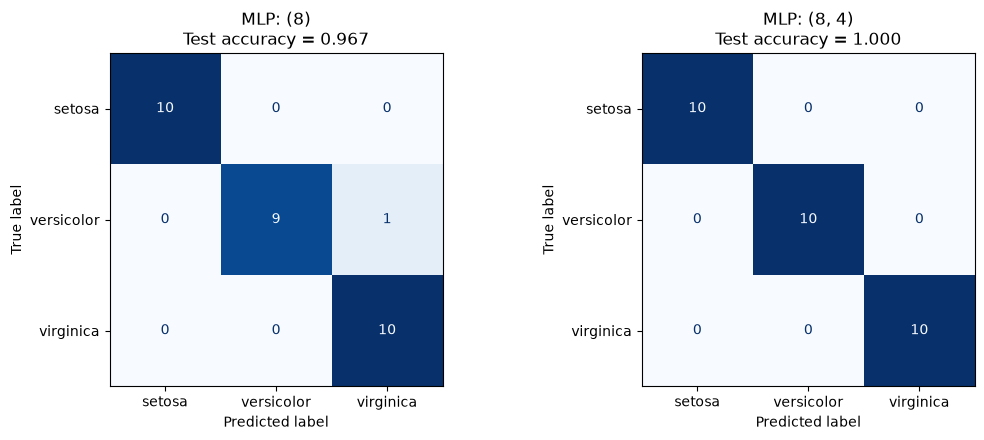

In [20]:
# Fit each architecture on the training set and compare their test-set confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for axis, (name, model) in zip(axes, architectures.items()):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, display_labels=iris.target_names,
        cmap='Blues', colorbar=False, ax=axis
    )
    axis.set_title(f'{name}\nTest accuracy = {accuracy:.3f}')

plt.tight_layout()
plt.show()

## Conclusion

The architecture with the higher mean cross-validation accuracy is selected above and evaluated on the separate test set. The two confusion matrices show the class-wise errors for both models. The two-layer model is preferred only when its cross-validation result is better; otherwise, the one-layer 8-neuron model is the simpler choice.